In [1]:
import logging
from multiprocessing.spawn import get_command_line
from operator import ge

from scipy.sparse import csc_matrix 
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy
import regpy.stoprules as rules
from numpy.core.numeric import ones_like
from regpy.discrs import UniformGrid, DirectSum
from regpy.hilbert import L2, Sobolev, Hm0_domain
import regpy.hilbert as hilbert
from regpy.operators import Operator, SquaredModulus, Vector_of_operators
from regpy.operators import CoordinateProjection, Identity
from regpy.operators import DirectSum as opDirectSum
from regpy.operators.PINEM import PINEM_g_to_data, complex_PINEM_g_to_data
from regpy.solvers import HilbertSpaceSetting
from regpy.solvers.irgnm import IrgnmCG
from regpy.solvers.newton import NewtonCG
from scipy.io import loadmat
from scipy.misc import ascent
from numpy.linalg import norm
from regpy.util.imshow_fig import imshow_fig

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s %(levelname)s %(name)-20s :: %(message)s'
)


In [2]:
class FixAmplitude(Operator):
    # Operator (a,phase) |-> (ampl, phase) for some fixed ampl
    # (This could be replaced by the operator phase |-> (ampl, phase), but this would
    # require more if statements in main.)
    def __init__(self, ampl, domain):
        self.ampl = ampl
        super().__init__(DirectSum(domain, domain), DirectSum(domain, domain))

    def _eval(self, x, differentiate):
        _, phase = self.domain.split(x)
        return self.codomain.join(self.ampl, phase)

    def _derivative(self, x):
        ampl, phase = self.domain.split(x)
        return self.codomain.join(0*ampl, phase)

    def _adjoint(self, x):
        ampl, phase = self.codomain.split(x)
        return self.domain.join(0*ampl, phase)

In [3]:
class FixPartsOfAmplitudeAndPhase(Operator):
    # Operator (ampl|_mask_a,phase|_mask_p) |-> (E(ampl|_mask_a)+prior_ampl, E(phase|_mask_p)+prior_phase) 
    # for some prior guess prior_ampl, prior_phase of amplitude and phase, masks (mask_a,mask_p)
    # for the regions where phase and amplitude are supposed to be reconstructed/improved. 
    # E extends functions by 0 
    def __init__(self, prior_ampl, prior_phase,mask_a,mask_p,domain):
        self.prior_ampl = prior_ampl
        self.prior_phase = prior_phase
        self.proj_a = CoordinateProjection(domain,mask_a)
        self.proj_p = CoordinateProjection(domain, mask_p)
        self.ext_a = self.proj_a.adjoint
        self.ext_p = self.proj_p.adjoint
        super().__init__(DirectSum(self.proj_a.codomain, self.proj_p.codomain), 
            DirectSum(domain, domain))

    def _eval(self, x, differentiate):
        ampl, phase = self.domain.split(x)
        return self.codomain.join(self.ext_a(ampl)+self.prior_ampl, 
             self.ext_p(phase)+self.prior_phase)

    def _derivative(self, x):
        ampl, phase = self.domain.split(x)
        return self.codomain.join(self.ext_a(ampl), self.ext_p(phase))

    def _adjoint(self, x):
        ampl, phase = self.codomain.split(x)
        return self.domain.join(self.proj_a(ampl), self.proj_p(phase))


def ampphase2complex(amp, phase):
    return amp * np.exp(1j * phase)


In [4]:
def load_experimental_data_2(filename):
    mat = loadmat(filename)
    g_map = mat['pm']['g_map'][0][0]
    mask = mat['pm']['mask'][0][0]
    mask_binary = mat['pm']['mask_binary'][0][0].astype(dtype=bool)
    px_size = mat['pm']['px_sizes'][0][0]
    px_size = px_size * 1e-9 #convert nm to m
    return g_map, mask, mask_binary, px_size


In [5]:
def simulated_data(complex_g=True,amplitude_known=1, parallel=True,N=30):
    # filename = r"./data/01_javier.mat"
    filename = r"./data/FresnelPinemMap_obj_javier_2.mat"
    g_map, mask, mask_binary, px_size = load_experimental_data_2(filename)
    fov = tuple(x*px_size for x in mask.shape)
    lambda_electron = 2.51e-12
    defocus = 900e-6
    fresnelNumber = np.prod(fov)/(defocus * lambda_electron)
    # Uniform grid
    N1,N2 = mask.shape
    A_Psi0_Multiplier = mask.astype(complex)
    boundary_mask = np.zeros_like(mask_binary)
    boundary_mask[0,:]=True; boundary_mask[-1,:]=True
    boundary_mask[:,0]=True; boundary_mask[:,-1]=True
    mask_binary = mask_binary & ~boundary_mask

    if complex_g:
        grid = UniformGrid(np.linspace(0, 1, N1, endpoint=False),
                           np.linspace(0, 1, N2, endpoint=False))
        op = complex_PINEM_g_to_data(grid, fresnelNumber, mask_binary,
                                     A_Psi0_Multiplier, N=N, parallel=parallel)
        if amplitude_known==1:
            op2 = SquaredModulus(grid.complex_space()) - np.abs(g_map)**2
            op = Vector_of_operators([op2, op])
        return op, grid, g_map, g_map, mask_binary
    else:
        grid = UniformGrid(np.linspace(0, 1, N1, endpoint=False),
                           np.linspace(0, 1, N2, endpoint=False))
        op = PINEM_g_to_data(grid, fresnelNumber, mask_binary,
                             A_Psi0_Multiplier, list_of_filters=[[10],[-10]], parallel=parallel)
        exact_solution = op.domain.join(np.log(np.abs(g_map)),
                                        np.unwrap(np.angle(g_map.T)).T)

        return op, grid, exact_solution, g_map, mask_binary, ~boundary_mask


In [6]:
def synthetic_data(complex_g=True, amplitude_known=1, parallel=True):
    # Example parameters
    fresnelNumber = 5e3    # Fresnel-number of the simulated imaging system, associated with the unit-lengthscale
    # in grid (i.e. with the size of one pixel for the above choice of grid)
    # noise_level = 0.0001      # Noise level in the simulated data

    N = 8
    # define grid
    Xdim = 256
    Ydim = 256
    grid = UniformGrid(np.linspace(0, 1, Xdim, endpoint=False),
                       np.linspace(0, 1, Ydim, endpoint=False))

    # define forward operator and its domain
    [Xco, Yco] = np.meshgrid(np.arange(-1, 1, 2/Xdim), np.arange(-1, 1, 2/Ydim))
    mask_p = (abs(Xco+0.2) <= 0.2) & (abs(Yco) <= 0.4)
    mask_p = mask_p | (abs((Xco-0.35)*(Xco-0.35)+(Yco-0.35)*(Yco-0.35)) <= 0.01)

    mask = (abs(Xco)<=0.8) & (abs(Yco)<=0.8)
    A_Psi0_Multiplier = np.ones(grid.shape, complex)

    # Create phantom image (= padded example-image)
    picture = ascent()
    g_map_amp = picture[-Xdim//2:, -Ydim//2:].astype(np.float64)/255
    g_map_amp *= 2
    g_map_phase = picture[:Xdim//2, :Ydim//2].astype(np.float64)/255
    g_map_phase *= 0.5*np.pi
    pad_amount = tuple([(grid.shape[0] - g_map_amp.shape[0])//2,
                       (grid.shape[1] - g_map_amp.shape[1])//2])
    g_map_amp = np.pad(g_map_amp, pad_amount, 'constant', constant_values=0)
    g_map_phase = np.pad(g_map_phase, pad_amount, 'constant', constant_values=0)
    g_map_phase = harmonic_extension(~mask | mask_p, g_map_phase*mask)
    g_map_amp = harmonic_extension(~mask | mask_p, g_map_amp*mask)
    g_map = ampphase2complex(g_map_amp, g_map_phase)
    # g_map /= 10*abs(g_map).max()
    # g_map += ones_like(g_map)
    g_map = g_map.astype(complex)*mask

    if complex_g:
        op = complex_PINEM_g_to_data(grid, fresnelNumber, mask,
                                     A_Psi0_Multiplier, N=N, parallel=parallel)
        if amplitude_known==1:
            op2 = SquaredModulus(grid.complex_space()) - np.abs(g_map)**2
            op = Vector_of_operators([op2, op])
    else:
        op = PINEM_g_to_data(grid, fresnelNumber, mask, A_Psi0_Multiplier, N=N, parallel=True)
        if amplitude_known==1:
            ampl_fix = FixAmplitude(np.abs(g_map), grid)
            op = op * ampl_fix

    if complex_g:
        exact_solution = g_map
    else:
        exact_solution = op.domain.join(np.abs(g_map), np.angle(g_map))
    return op, grid, exact_solution, g_map, mask & ~mask_p, mask_p


In [7]:
def harmonic_extension(mask, values, damping = 0):
    # harmonic extension of a function on part of a 2D regular grid  
    # input: 
    #     mask: binary mask with True at point where values are given.
    #           At the boundary mask must have values True.
    #     values: array of function values: only values at points where mask=True are relevant
    #     damping: The extension satisfies (-Delta + damping)u =0, so only for the default 
    #              damping = 0 the extension is harmonic. 
    #              damping >0 may be used to create initial guesses for synthetic data generated with damping=0.  
    # 
    # output:
    #     An array u which coincides with values at {mask=True}, and an approximation of a 
    #     harmonic function on {mask=False} which is globally continuous
    #   
    u = values.flatten()
    G = np.where(mask,0,1) # boolean to integer
    k_int = np.nonzero(G)  # integer coordinates of interior points
    k_ext = np.nonzero(1-G) # integer coordinates of exterior points
    G[k_int] = 1+np.arange(len(k_int[0]))

    G1 = G.flatten()
    [m,n] = G.shape
    # Indices of interior points
    p = np.where(G1)[0] # list of numbers of interior points in flattened array
    N = len(p)
    f = np.zeros((N,)) # right hand side of matrix equation 

    # Connect interior points to themselves with 4's.
    i = G1[p]-1
    j = G1[p]-1
    s = (damping/(m*n) + 4.)*np.ones(p.shape)

    # for k = north, east, south, west
    for k in [-1, n, 1, -n]:
        # Possible neighbors in k-th direction
        Q = G1[p+k]
        # Index of points with interior neighbors in k-th direction
        q = np.where(Q)[0]
        q_ext = np.where(Q==0)[0]
        # Connect interior points to neighbors with -1's.
        i = np.concatenate([i, G1[p[q]]-1])
        j = np.concatenate([j,Q[q]-1])
        s = np.concatenate([s,-np.ones(q.shape)])
        i_ext = G1[p[q_ext]]-1
        f[i_ext] = f[i_ext]+u[p[q_ext]+k]
    # sparse matrix with 5 diagonals
    negLap= csc_matrix((s, (i,j)),(N,N))
    u = values.copy()
    u[k_int]=spsolve(negLap,f)
    return u

### set parameters and initialize forward operator

In [8]:
real_data = True
complex_g = False
    ## amplitude_known == 0 -> no prior knowledge of amplitude
    # amplitude_known == 1 -> prior knowledge of amplitude everywhere
    # amplitude_known == -1 -> prior knowledge of amplitude only on mask_a
amplitude_known = -1
intensity = 1e6
if real_data:
    op, grid, exact_solution, g_map, mask_a, mask_p \
        = simulated_data(complex_g=complex_g, amplitude_known=amplitude_known)
    # regpar = 5e-2; sobolev_index = 2
    regpar = 1e-10; sobolev_index = 1
    regpar_step = 1/3
else:
    op, grid, exact_solution, g_map, mask_a, mask_p \
        = synthetic_data(complex_g=complex_g, amplitude_known=amplitude_known)
    if amplitude_known == -1:
        regpar = 1e-6 
    else:
        regpar = 5e-4
    sobolev_index = 1
    regpar_step = 1/3
    
if complex_g:
    # Hdomain = Sobolev(grid.complex_space(), index=sobolev_index)
    Hdomain = Hm0_domain(mask_a, dtype=complex, index = sobolev_index)
    projection = CoordinateProjection(grid.complex_space(),mask_a)
else:
    ## for global Sobolev norm
    # Hdomain = 0.5 * Sobolev(grid, index=sobolev_index) + L2(grid)  # Sobolev(grid, index=0.5)
    if amplitude_known == 1:
        Hdomain = 0.5*Hm0_domain(mask_p, index = sobolev_index) + L2(grid)
        projection = opDirectSum(*(CoordinateProjection(grid,mask_p),Identity(grid))) 
    if amplitude_known == -1: 
        Hdomain = Hm0_domain(mask_a, index = sobolev_index) + Hm0_domain(mask_p, index = sobolev_index)
if amplitude_known == 1:
    extension = projection.adjoint
    op_ext = op * extension
if amplitude_known == -1:
    prior_ampl = harmonic_extension(~mask_a,np.abs(g_map),damping =400)
    prior_phase = harmonic_extension(~mask_p,np.unwrap(np.angle(g_map.T)).T,damping =0)
     #_, (ax1,ax2) = plt.subplots(1,2)
        #ax1.imshow(prior_ampl)
        #ax2.imshow(prior_phase)
    extension = FixPartsOfAmplitudeAndPhase(prior_ampl,prior_phase, \
        mask_a, mask_p, grid)
    _,deriv = extension.linearize(extension.domain.zeros())
    projection = deriv.adjoint

        # as extension is also needed for plotting, a copy is required to avoid errors 
        # on the use of revoked copies 
    extension2 = deepcopy(extension)
        #extension2 = FixPartsOfAmplitudeAndPhase(abs(g_map) * (~mask_a),np.zeros(grid.shape), \
        #    mask_a, mask_p, grid)
    op_ext = op * extension2


### generate synthetic data and define setting

In [9]:
flat_codomain = DirectSum(*op.codomain.summands, flatten=True)
if complex_g and amplitude_known==1:
    #exact_data = op(exact_solution)
    exact_data = op_ext(projection(exact_solution))
    exact_data_comp = op.codomain.split(exact_data)
    noisy_data = exact_data_comp #np.random.poisson(intensity * exact_data_comp[1])/intensity
    data = op.codomain.join(np.zeros_like(exact_data_comp[0]), noisy_data)
    Hcodomain0 = L2(grid)
    data_comp = flat_codomain.split(data)
    Hcodomain1 = L2(grid, weights=(1+intensity*data_comp[1])/intensity)
    for j in range(2, len(flat_codomain)):
        Hcodomain1 = Hcodomain1 + L2(grid, weights=(1+intensity*data_comp[j])/intensity)
    Hcodomain = hilbert.DirectSum(Hcodomain0, Hcodomain1)
else:
    exact_data = op(exact_solution)
    #if amplitude_known = 0: 
    #    exact_data = op_ext(projection(exact_solution))
    #elif amplitude_known = -1: 
    #    exact_data = op_ext(projection(exact_solution-))
    data = np.random.poisson(intensity * exact_data)/intensity
    data_comp = op.codomain.split(data)
    # define codomain Gram matrix based on observed data to approximate log-likelihood
    Hcodomain = L2(grid, weights=(1+intensity*data_comp[0])/intensity)
    for j in range(1, len(data_comp)):
        Hcodomain = Hcodomain + L2(grid, weights=(1+intensity*data_comp[j])/intensity)
setting = HilbertSpaceSetting(op=op_ext, Hdomain=Hdomain, Hcodomain=Hcodomain)

### set up initial guess

In [10]:
if complex_g:
    if amplitude_known==1:
        init_vec = abs(g_map).astype(complex)
    else:
        init_vec = grid.complex_space().ones() * mask_a
else:
    angle = np.deg2rad(10)
    X, Y = np.meshgrid(np.linspace(0, 1, np.size(mask_a, 1)), np.linspace(0, 1, np.size(mask_a, 0)))
    init_phase_gradient = -1 * (np.sin(angle)*X + np.cos(angle)*Y) * 2*np.pi * 3 + 2.5
    if amplitude_known==1:
        # init_vec = op.domain.join(np.abs(g_map), \
        #         norm(np.angle(g_map).ravel(),1)/norm(mask.ravel(),1) * mask)
        init_vec = op.domain.join(np.abs(g_map),
                                    init_phase_gradient * mask_p)
    elif amplitude_known == 0:
        # init_vec = op.domain.join(mask, \
        #     norm(np.angle(g_map).ravel(),1)/norm(mask.ravel(),1) * mask)
        init_vec = op.domain.join(mask_a.astype(dtype=np.float),
                                    init_phase_gradient * mask_p)
    else:
        init_vec = op.domain.join(np.zeros_like(prior_ampl),
                                    np.zeros_like(prior_phase))
# init_vec_proj = init_vec
init_vec_proj = projection(init_vec)


### define regularization method

In [11]:
stoprule = (
        rules.Discrepancy(
            setting.Hcodomain.norm,
            data,
            noiselevel=setting.Hcodomain.norm(np.sqrt(data/intensity)),
            tau=1.0
        ) +
        rules.CountIterations(max_iterations=50,while_type=True) 
    )
solver = IrgnmCG(
    setting, data, init=init_vec_proj,
    regpar=regpar, regpar_step=regpar_step,
    inner_it_logging_level=logging.INFO
    )

rel. error 0.005162389590536129 40 15


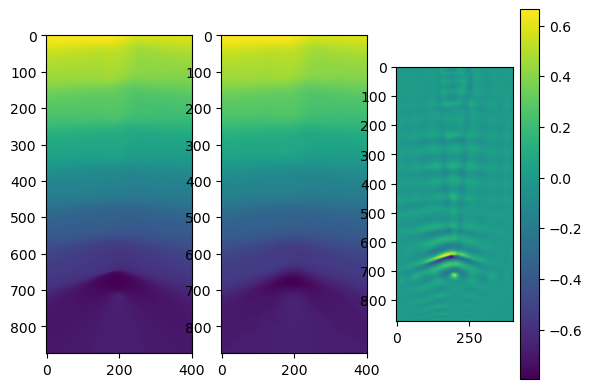

In [16]:
from regpy.discrs import Grid
from regpy. discrs.tensor_bases import ChebyshevBasis, LegendreBasis
import matplotlib.pyplot as plt
from scipy.optimize import lsq_linear
M=40
N=15
data = np.unwrap(np.angle(g_map.T)).T
fig, (ax1,ax2,ax3) =plt.subplots(1,3)
ax1.imshow(data)
m,n = data.shape
x = np.linspace(-1,1.,m)
y = np.linspace(-1,1.,n)
grid = Grid(x,y)
Bas = LegendreBasis((M,N),grid)
T = Bas.asLinearOperator()
dom = Bas.domain
codom = Bas.codomain
flatdata = codom.flatten(data)
res = lsq_linear(T,flatdata,verbose=0)
coeff_rec = res.x

data_rec = codom.fromflat(T(coeff_rec))
print('rel. error', np.linalg.norm(data[:]-data_rec[:])/np.linalg.norm(data[:]),M,N)
ax2.imshow(data_rec)
ax3.imshow(dom.fromflat(np.log(np.abs(coeff_rec)+1e-10)))
plt.imshow(data- data_rec)
plt.colorbar()